C:\Users\hayde\AppData\Local\Temp\ipykernel_18020\1739786261.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab10')  # Use 'tab10', 'tab20', or 'Set1' for distinct colors


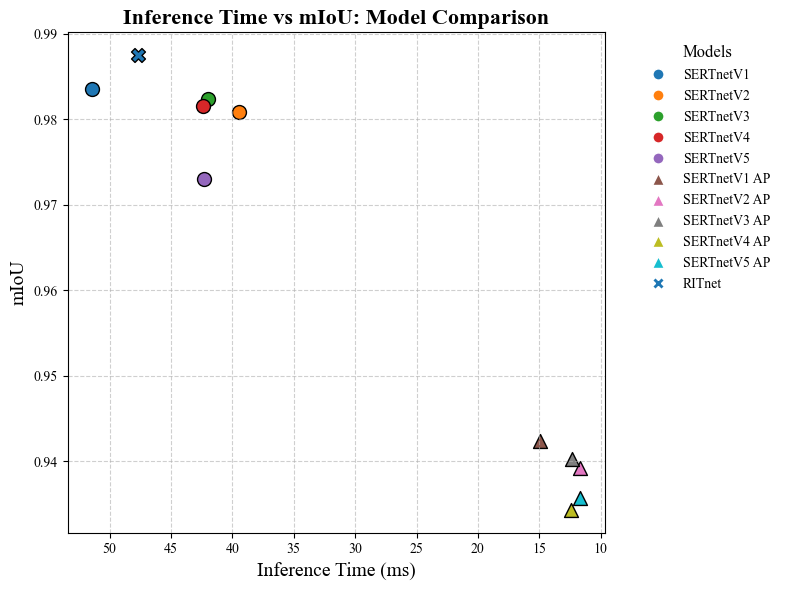

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib.cm import get_cmap

# Set Times New Roman as the font
rcParams['font.family'] = 'Times New Roman'

# Data from your speed tests (replace these with your actual results)
models = ['SERTnetV1', 'SERTnetV2', 'SERTnetV3', 'SERTnetV4', 'SERTnetV5', 
          'SERTnetV1 AP', 'SERTnetV2 AP', 'SERTnetV3 AP', 'SERTnetV4 AP', 'SERTnetV5 AP', 'RITnet']
inference_times = np.array([51.43, 39.45, 42.02, 42.39, 42.28, 14.91, 11.67, 12.31, 12.43, 11.71, 47.66])  # Inference times in ms
accuracies = np.array([0.98360438, 0.98081104, 0.9824066, 0.981515, 0.97299985, 0.94236561, 0.93927223, 0.94029171, 0.93432966, 0.93570602, 0.98752444])  # Replace with actual accuracies
markers = ['o', 'o', 'o', 'o', 'o', '^', '^', '^', '^', '^', 'X']  # Add more markers if needed
# Use a qualitative colormap for distinct colors
cmap = get_cmap('tab10')  # Use 'tab10', 'tab20', or 'Set1' for distinct colors
colors = cmap(np.arange(len(models)) % cmap.N)  # Cycle through the colormap if there are more models than colors

# Create the scatter plot
plt.figure(figsize=(8, 6))

# Add labels for each point
for i, model in enumerate(models):
    plt.scatter(inference_times[i] , accuracies[i], color=colors[i], marker=markers[i], s=100, edgecolor='black', label=model)

# Formatting
plt.title('Inference Time vs mIoU: Model Comparison', fontsize=16, weight='bold')
plt.xlabel('Inference Time (ms)', fontsize=14)
plt.ylabel('mIoU', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().invert_xaxis() # Invert x-axis for better readability
# Add a legend (key) for the models
handles = [plt.Line2D([0], [0], marker=markers[i], color='w',  markerfacecolor=colors[i], markersize=8, label=model) for i, model in enumerate(models)]
plt.legend(handles, models, loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=10, title='Models', title_fontsize=12, frameon=False)

# Save the plot as a high-resolution image for IEEE paper
plt.tight_layout()
plt.savefig('inference_time_vs_accuracy_with_distinct_colors.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()